# 01_market_price_exploration
what does the ablerta electricity market actually look like, and what characteristics make it difficult to model?

### Research Question
What are the fundamental statistical characterists of Alberta pool prices and electricity demand from 2020-2025, and what do they suggest about future modelling challenges?

#### Load Raw Market Data

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "src"))
from load_data import load_market_data

# load clean market data
# timestamp, pool_price, demand — 2020-2025 hourly
df = load_market_data()

print(f"Shape: {df.shape}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(df.head())

Shape: (48935, 9)
Date range: 2020-01-01 00:00:00 to 2025-07-31 23:00:00
            timestamp  pool_price  demand  IMPORT_BC  IMPORT_MT  IMPORT_SK  \
0 2020-01-01 00:00:00       30.24    9467          0         80          0   
1 2020-01-01 01:00:00       29.43    9361          0        125          0   
2 2020-01-01 02:00:00       29.66    9286          0        125          0   
3 2020-01-01 03:00:00       28.19    9209          0        125          0   
4 2020-01-01 04:00:00       31.17    9195          0        125          0   

   EXPORT_BC  EXPORT_MT  EXPORT_SK  
0          0          0          0  
1          0          0          0  
2          0          0          0  
3          0          0          0  
4          0          0          0  


The pool_price_2020_2025.csv contains hourly Alberta electricity market information from 2020-2025. 

in addition to pool prices and demand, it includes generation asset output and intertie flows, making it possible to study both market outcomes and underlying grid conditions. 

the first objective is simply understanding what information is available before building any predicitive models. 

print(df.head())
print(df.columns)

Observations:
- dataset contains roughly 49,000 hourly observations
- 236 columns are avaiable
- most columns represent individual generating assets
- key market variables include:
    - actual pool price
    - alberta internal load (AIL)
    - imports and exports
    - hour-ahead pool price forecast

Takeaway:

the dataset is much richer than a typical academic electricity dataset.

rather than only containing prices and demand, it includes a large portion of the underlying physical system responsible for price foundation. 

this creates opportunities for both market analysis and power-system analysis later in this project.

In [6]:
print(df.dtypes)

timestamp     datetime64[us]
pool_price           float64
demand                 int64
IMPORT_BC              int64
IMPORT_MT              int64
IMPORT_SK              int64
EXPORT_BC              int64
EXPORT_MT              int64
EXPORT_SK              int64
dtype: object


Goal:

Reduce the dataset to the two variables that drive most electricity market discussions: 
- price
- demand

this provides a clean starting point before adding weather, fuel, generation mix, and grid-state variables. 

In [10]:
# sanity check — verify no missing values in core columns
print(df.isnull().sum())
print(f"\nShape: {df.shape}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")

timestamp     0
pool_price    0
demand        0
IMPORT_BC     0
IMPORT_MT     0
IMPORT_SK     0
EXPORT_BC     0
EXPORT_MT     0
EXPORT_SK     0
dtype: int64

Shape: (48935, 9)
Date range: 2020-01-01 00:00:00 to 2025-07-31 23:00:00


the core market variables contain no missing observations. 

this is extremely valuable because:
- no imputation is required
- statistical results are easier to interpret
- modeling errors are less likely to be caused by data quality issues

#### Statistical Overview
Question: 

how volatile are alberta prices and demand?

In [12]:
df.describe()

,timestamp,pool_price,demand,IMPORT_BC,IMPORT_MT,IMPORT_SK,EXPORT_BC,EXPORT_MT,EXPORT_SK
count,48935,48935.000000,48935.000000,48935.000000,48935.000000,48935.000000,48935.000000,48935.000000,48935.000000
mean,2022-10-16 11:39:16.497394,94.942801,9846.494043,172.715848,104.335281,50.792255,145.224849,20.597282,4.197568
min,2020-01-01 00:00:00,0.000000,7579.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2021-05-24 18:30:00,30.570000,9257.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000
50%,2022-10-16 12:00:00,45.310000,9837.000000,100.000000,100.000000,45.000000,0.000000,0.000000,0.000000
75%,2024-03-09 04:30:00,78.760000,10457.000000,321.000000,169.000000,90.000000,150.000000,26.000000,0.000000
max,2025-07-31 23:00:00,999.990000,12384.000000,756.000000,335.000000,159.000000,1035.000000,393.000000,181.000000
std,NaN,153.904992,827.526124,199.288031,79.749153,56.066194,269.217590,42.137984,19.254785


Key Findings

pool price:
- mean: $94.94/MWh
- median: $45.31/MWh
- maximum: $999.99/Mwh
- minimum: $0.00/MWh

demand:
- mean: 9,846 MW
- median: 9,837 MW
- maximum: 12,384 MW
- minimum: 7,579 MW

interpretation: 

1. pool prices are highly skewed. the mean is more than double the median. this suggests a small number of extremely expensive hours are pulling the average upward. 
alberta prices are unusually moderate, but occasionally become extremely expensive. 

2. price spikes are enormous. maximum observed price was $999.99/MWh - which is the market cap. the existence of frequent cap-pfrice events suggests Alberta experiences occasional scarcity conditions where supply becomes extremely tight. 
this immediately hints that scarcity events may need to be modeled separately from normal market conditions. 

3. demand is much more stable than price. this suggests demand will likely explain only part of market behaviour

#### Alberta Pool Price Through Time

Question:

does alberta price behaviour appear stable through time?

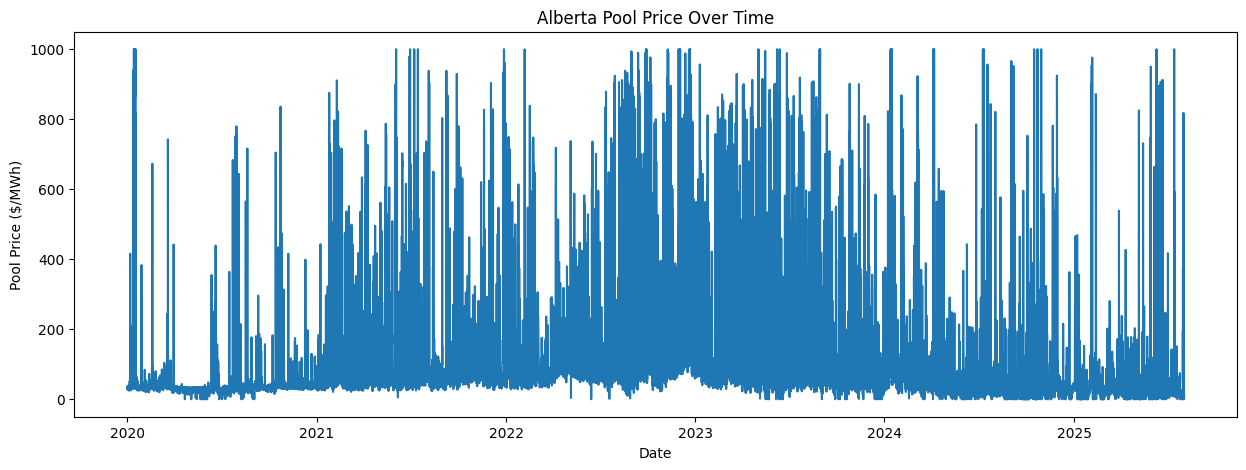

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(df['timestamp'], df['pool_price'])
plt.title("Alberta Pool Price Over Time")
plt.xlabel("Date")
plt.ylabel("Pool Price ($/MWh)")
plt.show()

Observations:

the series shows:
- long periods of low prices
- occasional extreme spikes
- clusters of volatility
- increasing frequency of high-price events between 2022 and 2024

interpretation: 

the market does not appear stationary. different periods exhibit different volatility regimes. 

this suggests:
- one model may not describe all years equally well
- regime-based analysis may eventually be required

structural shifts may have occurred during the sample period (this would make sense given both COVID and the Russian-Ukraine war were major world events that would have had an affect on the energy markets).

other explanations: 
- coal retirements 
- renewable penetration
- changing reserve margins

#### Alberta Demand Through Time

Question:

How does demand evolve over time?

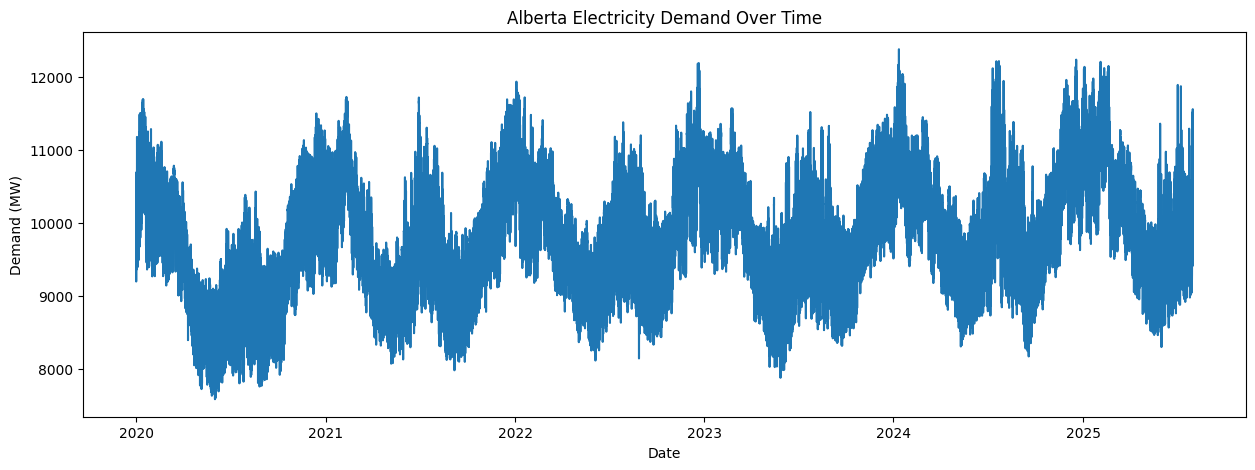

In [16]:
plt.figure(figsize=(15,5))
plt.plot(df["timestamp"], df['demand'])
plt.title("Alberta Electricity Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.show()


observations: 
- strong seasonal cycles
- gradual long-term growth
- significantly lower volatility than prices

interpretation:

demand appears highly structured and predictable. unlike price spikes, demand behaviour follows recurring patterns. this suggests weather and seasonaility should be valuable forecasting inputs. 

#### Highest Price Hours

Question: 

What conditions exist during Alberta's most expensive hours?

In [17]:
df.sort_values("pool_price", ascending=False).head(20)

,timestamp,pool_price,demand,IMPORT_BC,IMPORT_MT,IMPORT_SK,EXPORT_BC,EXPORT_MT,EXPORT_SK
35371,2024-01-13 19:00:00,999.99,11268,215,17,103,0,0,0
13287,2021-07-07 16:00:00,999.99,10678,322,126,0,0,0,0
25530,2022-11-29 18:00:00,999.99,11400,396,158,60,0,0,0
42319,2024-10-29 08:00:00,999.99,10445,369,93,0,0,0,0
13288,2021-07-07 17:00:00,999.99,10640,329,129,0,0,0,0
25577,2022-12-01 17:00:00,999.99,11564,421,165,0,0,0,0
25578,2022-12-01 18:00:00,999.99,11549,482,190,60,0,0,0
25601,2022-12-02 17:00:00,999.99,11497,480,189,60,0,0,0
13286,2021-07-07 15:00:00,999.99,10667,322,126,0,0,0,0
35347,2024-01-12 19:00:00,999.99,11803,550,7,25,0,0,0


findings:

many of the highest-price observations occur at:
- winter evenings
- summer afternoons
- shoulder-season periods (october, april)

many events occur around 17:00 - 20:00 - which is when demand remains elevated and solar production is declining.

important observation:

demand during these scarcity events is not always extreme. if it was demand alone which caused scarcity pricing, we would expect only the highest-demand hours to be represented in in the price cap. instead, moderate demand can still produce extreme prices in combination with other factors:
- low wind generation
- generator outages
- reserve shortages
- import limitations
- transmission constraints

## Daily Price Behaviour

Question:

are alberta price movements persistent market regimes, or simply isolated hourly spikes?

In [18]:
daily_prices = df.resample(
    "D",
    on = 'timestamp'
)['pool_price'].mean()

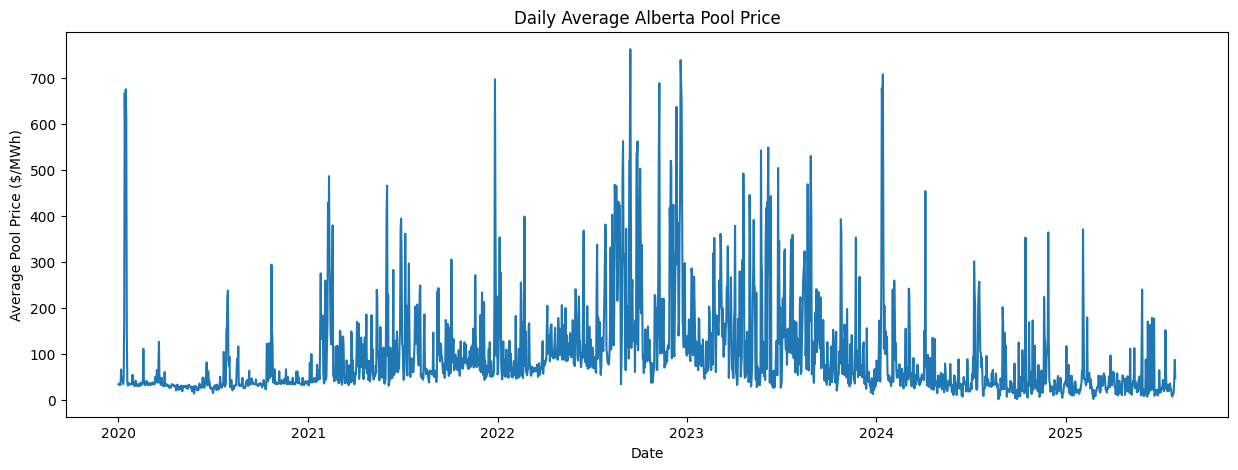

In [19]:
plt.figure(figsize=(15,5))
plt.plot(daily_prices.index, daily_prices.values)
plt.title("Daily Average Alberta Pool Price")
plt.xlabel("Date")
plt.ylabel("Average Pool Price ($/MWh)")
plt.show()

Interpretation:

the daily average price series smooths out individual scarcity events and reveals broader market regimes. 

key observations:
- alberta experiences multi-week and multi-month pricing regimes rather than pureply random hourly volatility
- elevated daily average prices appear in clusters, suggesting common underlying drivers
- daily averages remain relatively stable most of the time despite extreme hourly spikes
- this implies that most volatility is concentrated in a small subset of hours rather than evenly distributetd throughout the day

scarcity events dominate headlines, but long-run price behaviour is driven by broader market fundamentals and changing system conditions

#### January 13, 2024 Scarcity Event

Question:

what does a real alberta scarcity event look like in practice?

In [20]:
event = df[
    (df["timestamp"] >= "2024-01-13 00:00:00") &
    (df["timestamp"] <= "2024-01-14 00:00:00")
]

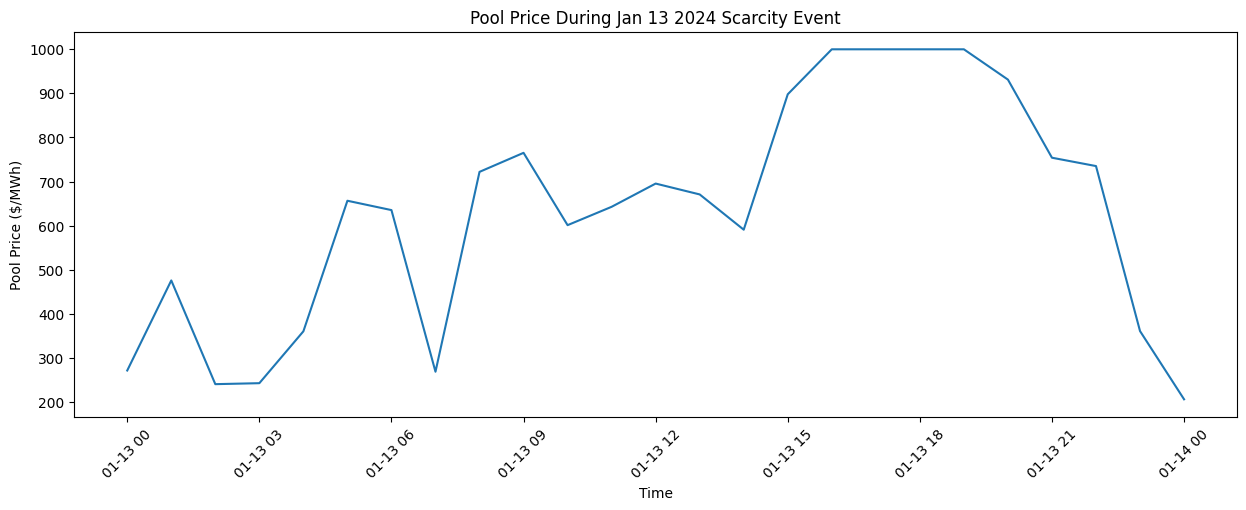

In [21]:
# intraday price action during the Jan 13 2024 scarcity event
plt.figure(figsize=(15,5))

plt.plot(event["timestamp"], event["pool_price"])

plt.title("Pool Price During Jan 13 2024 Scarcity Event")
plt.xlabel("Time")
plt.ylabel("Pool Price ($/MWh)")

plt.xticks(rotation=45)

plt.show()

interpretation:

this event provides a real example of alberta's energy-only market design.

observations:
- prices remained relatively normal for much of the day
- prices then rapidly escalated toward the market cap
- scarcity pricing appeared suddenly rather than gradually

this behaviour suggests that alberta pricing contains threshold effects:
- when reserves are adequate, prices remain relatively stable
- once reserve margins become sufficiently tight, prices can increase dramatically

alberta prices are not goverened by a smooth linear relationship between supply and demand. scarcity events exhibit nonlinear behaviour

#### Demand During Scarcity

Question:

was the january 2024 scarcity event caused solely by unusually high demand?

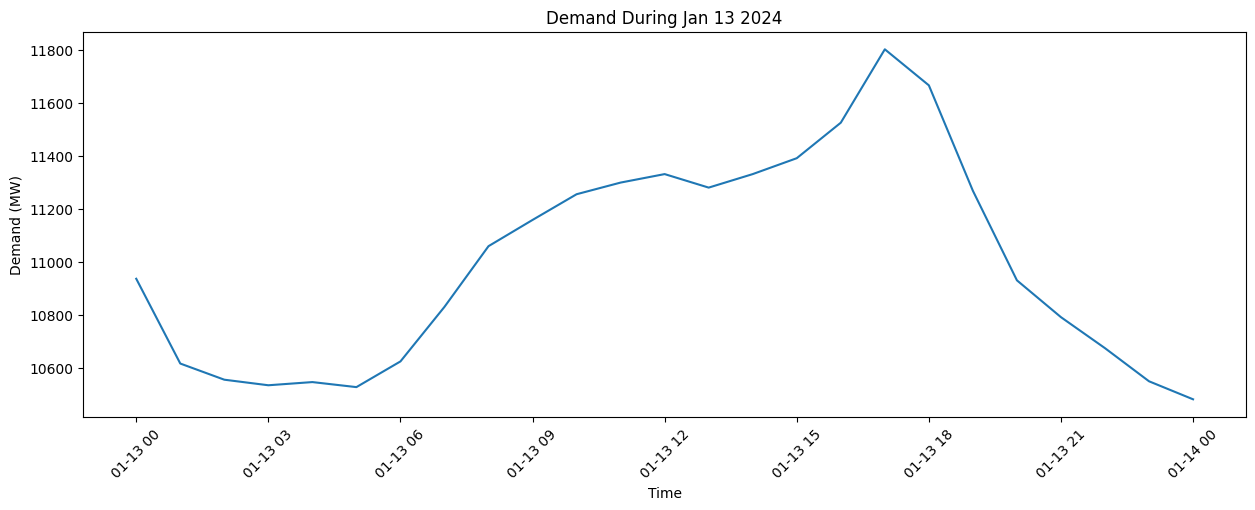

In [22]:
# intraday demand action during the Jan 13 2024 scarcity event
plt.figure(figsize=(15,5))

plt.plot(event["timestamp"], event["demand"])

plt.title("Demand During Jan 13 2024")
plt.xlabel("Time")
plt.ylabel("Demand (MW)")

plt.xticks(rotation=45)

plt.show()

Interpretation:

Demand was elevated during the event, but demand alone does not explain the magnitude of the price response.

Several other periods in the dataset exhibit similar demand levels without producing $999/MWh prices.

This suggests:
- High demand is often necessary for scarcity.
- High demand alone is not sufficient.

Additional system conditions are likely required:
- low renewable generation
- generator outages
- reserve shortages
- transmission limitations
- import constraints

Scarcity events appear to be driven by multiple simultaneous stress factors rather than demand alone.

#### Daily Maximum Prices

Question:

how frequently does alberta experience extreme scarcity pricing?

In [23]:
daily_max = df.resample(
    "D",
    on="timestamp"
)["pool_price"].max()

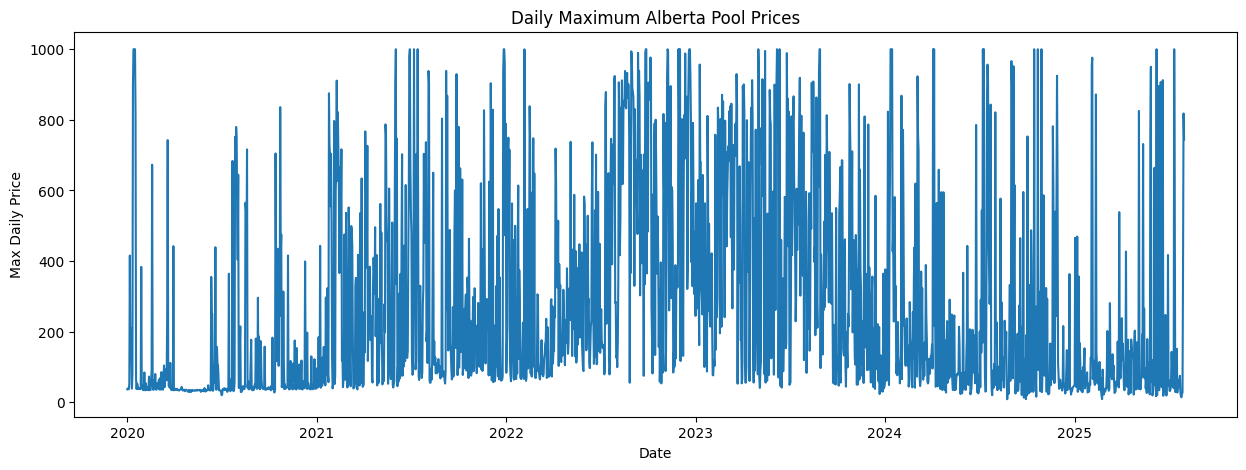

In [24]:
plt.figure(figsize=(15,5))

plt.plot(daily_max.index, daily_max.values)

plt.title("Daily Maximum Alberta Pool Prices")
plt.xlabel("Date")
plt.ylabel("Max Daily Price")

plt.show()

Interpretation:

Daily maximum prices reveal events that are largely hidden by daily averages.

Observations:
- Many days contain ordinary prices.
- Certain days contain isolated extreme spikes.
- Maximum prices frequently reach the market cap of $999.99/MWh.

This indicates that:
- Alberta’s average market conditions are often benign.
- Market outcomes are heavily influenced by rare but extreme scarcity periods.

Understanding extreme events may be more important than understanding average conditions.

#### Intraday Price Patterns

Question:

do alberta pool prices exhibit predictable hourly behaviour?

In [25]:
df["hour"] = df["timestamp"].dt.hour

hourly_avg = df.groupby("hour")["pool_price"].mean()

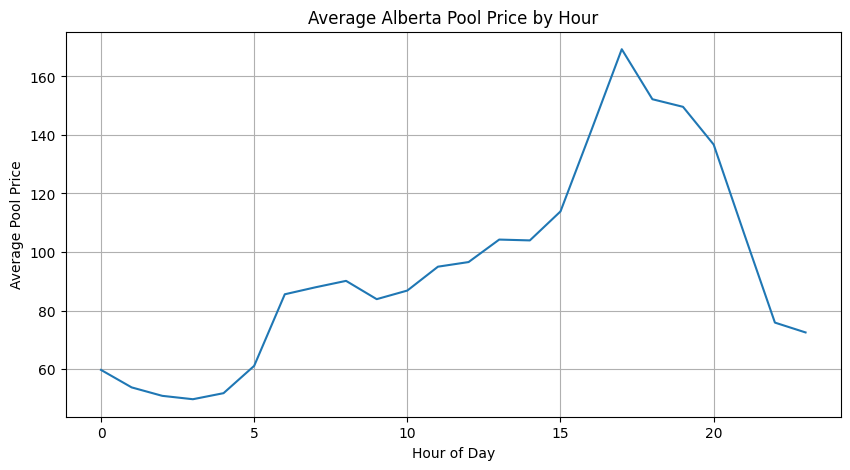

In [26]:
plt.figure(figsize=(10,5))

plt.plot(hourly_avg.index, hourly_avg.values)

plt.title("Average Alberta Pool Price by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Pool Price")

plt.grid(True)

plt.show()

Interpretation:

Average hourly prices reveal the typical daily market rhythm.

Likely observations:
- Lower prices overnight.
- Increasing prices during morning load growth.
- Highest prices during late afternoon and early evening.
- Declining prices overnight.

These patterns broadly reflect demand behaviour and generator dispatch economics.

Even in a volatile market, strong intraday structure exists.

#### Distribution of Alberta Pool Prices

Question:

what does the statistical distribution of alberta prices look like?

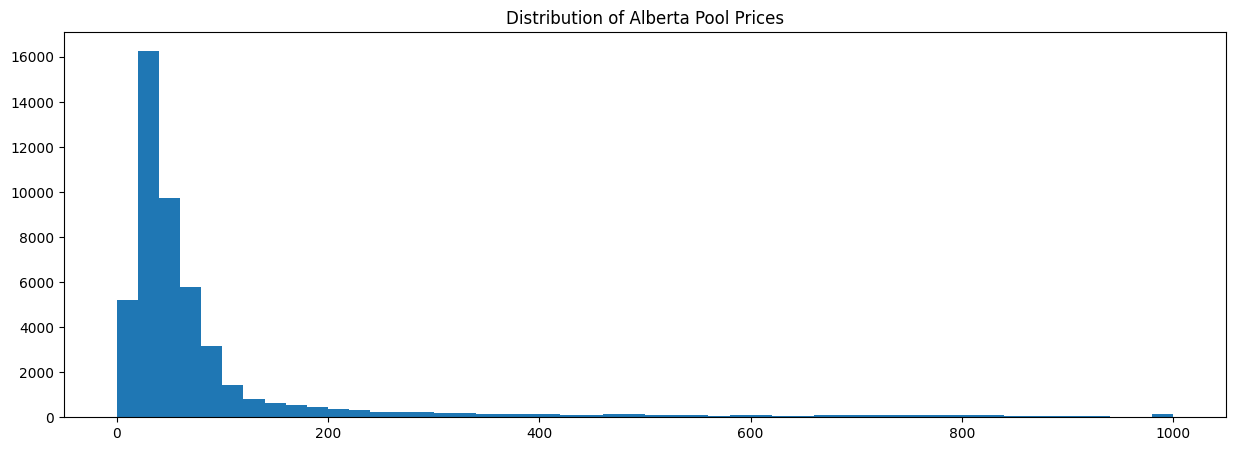

In [40]:
plt.figure(figsize=(15,5))
plt.hist(df['pool_price'], bins=50)
plt.title("Distribution of Alberta Pool Prices")
plt.show()


Interpretation:

The price distribution is highly non-normal.

Characteristics:
- Strong concentration of observations at relatively low prices.
- Long right tail extending toward $999/MWh.
- Significant positive skewness.

This is one of the defining features of electricity markets.

Unlike most commodities:
- prices cannot go negative indefinitely
- supply and demand must balance instantly
- scarcity can create very large upside price moves

Electricity markets are naturally asymmetric. Extreme upside events dominate risk.

#### Price vs Demand Through the Day

Question: 

Does demand explain the daily pattern of electricity prices?

In [29]:
df['hour'] = df['timestamp'].dt.hour
hourly_avg = df.groupby('hour')['pool_price'].mean()

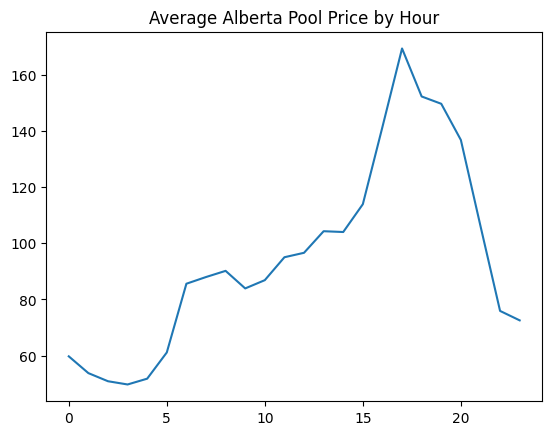

In [30]:
plt.plot(hourly_avg)
plt.title("Average Alberta Pool Price by Hour")
plt.show()

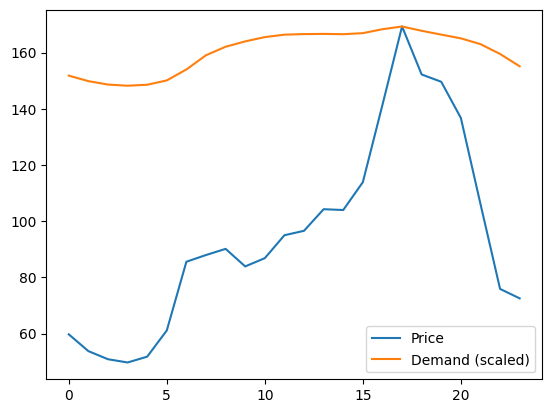

In [32]:
hourly_demand = df.groupby("hour")["demand"].mean()

plt.plot(hourly_avg, label="Price")
plt.plot(hourly_demand / hourly_demand.max() * hourly_avg.max(), label="Demand (scaled)")
plt.legend()
plt.show()

Interpretation:

Comparing normalized demand and price patterns allows us to assess whether price simply follows load.

Observations typically include:
- Similar overall shape.
- Stronger price increases during peak hours than demand alone would imply.

This suggests that marginal system conditions matter.

As the system approaches its operational limits:
- each additional MW becomes more expensive
- prices rise faster than demand

Price generally follows demand, but not proportionally.

#### Daily Price Volatility

Question:

When is alberta most volatile?

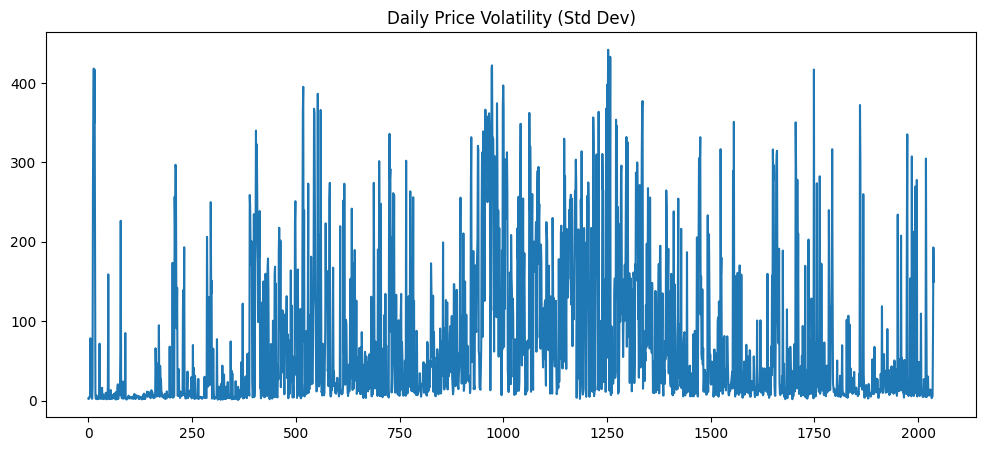

In [33]:
daily_vol = df.groupby(
    df['timestamp'].dt.date
)['pool_price'].std()

plt.figure(figsize=(12,5))
plt.plot(daily_vol.values)
plt.title("Daily Price Volatility (Std Dev)")
plt.show()

Interpretation:

Volatility highlights periods where prices fluctuate significantly within a single day.

High-volatility days often correspond to:
- scarcity conditions
- renewable variability
- system stress
- unexpected outages

This metric becomes especially useful later when identifying market regimes.

Volatility itself may be a useful indicator of changing grid conditions.

#### Extreme Price Events

Question:

When do alberta's most servere price spikes occur?

In [35]:
top_spikes = df.sort_values('pool_price', ascending=False).head(20)
top_spikes


,timestamp,pool_price,demand,IMPORT_BC,IMPORT_MT,IMPORT_SK,EXPORT_BC,EXPORT_MT,EXPORT_SK,hour
35371,2024-01-13 19:00:00,999.99,11268,215,17,103,0,0,0,19
13287,2021-07-07 16:00:00,999.99,10678,322,126,0,0,0,0,16
25530,2022-11-29 18:00:00,999.99,11400,396,158,60,0,0,0,18
42319,2024-10-29 08:00:00,999.99,10445,369,93,0,0,0,0,8
13288,2021-07-07 17:00:00,999.99,10640,329,129,0,0,0,0,17
25577,2022-12-01 17:00:00,999.99,11564,421,165,0,0,0,0,17
25578,2022-12-01 18:00:00,999.99,11549,482,190,60,0,0,0,18
25601,2022-12-02 17:00:00,999.99,11497,480,189,60,0,0,0,17
13286,2021-07-07 15:00:00,999.99,10667,322,126,0,0,0,0,15
35347,2024-01-12 19:00:00,999.99,11803,550,7,25,0,0,0,19


Interpretation:

Several important observations emerge:
- Extreme spikes occur across multiple years.
- Demand levels vary substantially.
- Not all scarcity events occur during maximum annual demand.

This reinforces a major conclusion - demand alone does not explain scarcity.

Other operational variables must be contributing.

Extreme price events are system-state events, not simply high-demand events.

In [36]:
top_spikes['hour'] = top_spikes['timestamp'].dt.hour
top_spikes['hour'].value_counts()


hour
18    5
17    5
19    3
9     2
16    1
8     1
15    1
20    1
10    1
Name: count, dtype: int64

Interpretation:

Most extreme price spikes occur during the late afternoon and early evening.

This is highly consistent with power system fundamentals:
- demand remains elevated
- solar generation is declining
- thermal units may already be heavily utilized
- operating reserves are tighter

This pattern resembles the “net load ramp” challenge observed in many renewable-heavy grids.

Scarcity is strongly concentrated during evening transition periods.

#### Annual Price Regimes

Question:

how has alberta's average price environment changed over time?

In [38]:
df['year'] = df['timestamp'].dt.year
yearly_avg = df.groupby('year')['pool_price'].mean()


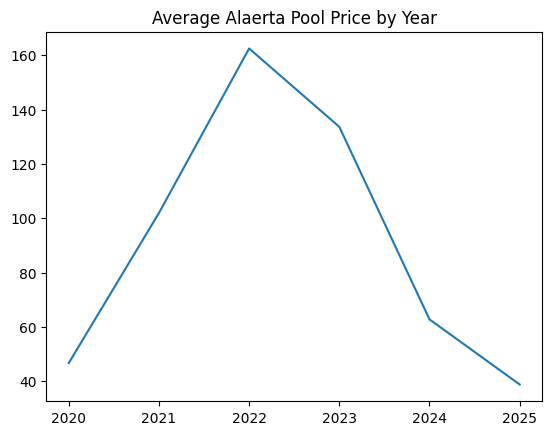

In [39]:
plt.plot(yearly_avg)
plt.title("Average Alaerta Pool Price by Year")
plt.show()

Interpretation:

Average annual prices provide a high-level view of changing market regimes.

Potential drivers include:
- natural gas prices
- coal retirement
- renewable growth
- economic conditions
- weather variation
- broader energy market disruptions

This analysis later motivated the inclusion of AECO gas prices as a key explanatory variable.

Alberta prices operate within broader multi-year regimes, not just hourly fluctuations.